<table>
<tr><td><img style="height: 150px;" src="images/geo_hydro1.jpg"></td>
<td bgcolor="#FFFFFF">
    <p style="font-size: xx-large; font-weight: 900; line-height: 100%">AG Dynamics of the Earth</p>
    <p style="font-size: large; color: rgba(0,0,0,0.5);">Juypter notebooks</p>
    <p style="font-size: large; color: rgba(0,0,0,0.5);">Georg Kaufmann</p>
    </td>
</tr>
</table>

----
# Hand-written digits

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn import datasets

----
## The `digits` dataset

Contains 1797 images of hand-written digits.

Stored as dictionary (key-value pairs) with the keys:
1. data (contains the 8x8 images as array)
2. target (the numbers associated to each image)
3. target_names (the 10 digits, 0-9)
4. images (the images as 8x8 arrays)
5. DESCR (description of data set)

In [2]:
digits = datasets.load_digits()

In [3]:
n_samples = len(digits.images)
print(n_samples)
n_samples = len(digits['images'])
print(n_samples)

1797
1797


In [4]:
print (digits['DESCR'])

.. _digits_dataset:

Optical recognition of handwritten digits dataset
--------------------------------------------------

**Data Set Characteristics:**

    :Number of Instances: 5620
    :Number of Attributes: 64
    :Attribute Information: 8x8 image of integer pixels in the range 0..16.
    :Missing Attribute Values: None
    :Creator: E. Alpaydin (alpaydin '@' boun.edu.tr)
    :Date: July; 1998

This is a copy of the test set of the UCI ML hand-written digits datasets
https://archive.ics.uci.edu/ml/datasets/Optical+Recognition+of+Handwritten+Digits

The data set contains images of hand-written digits: 10 classes where
each class refers to a digit.

Preprocessing programs made available by NIST were used to extract
normalized bitmaps of handwritten digits from a preprinted form. From a
total of 43 people, 30 contributed to the training set and different 13
to the test set. 32x32 bitmaps are divided into nonoverlapping blocks of
4x4 and the number of on pixels are counted in each blo

Check **target numbers** and **target names**:

In [5]:
print('Target numbers: ',len(digits['target']))
print(digits['target_names'])

Target numbers:  1797
[0 1 2 3 4 5 6 7 8 9]


Check **image numbers** and **first image**, both as `image` and `data` array:

In [6]:
print('Image numbers: ',len(digits['images']))
i=1200
print(digits['images'][i])
print(digits['data'][i])
print(digits['target'][i])

Image numbers:  1797
[[ 0.  0. 12. 16. 16. 12.  0.  0.]
 [ 0.  0.  6.  4. 10. 13.  1.  0.]
 [ 0.  0.  0.  0. 13.  9.  0.  0.]
 [ 0.  0.  5.  9. 16. 16. 12.  0.]
 [ 0.  3. 16. 16. 11.  3.  0.  0.]
 [ 0.  0.  7. 13.  0.  0.  0.  0.]
 [ 0.  0. 11.  8.  0.  0.  0.  0.]
 [ 0.  0. 16.  3.  0.  0.  0.  0.]]
[ 0.  0. 12. 16. 16. 12.  0.  0.  0.  0.  6.  4. 10. 13.  1.  0.  0.  0.
  0.  0. 13.  9.  0.  0.  0.  0.  5.  9. 16. 16. 12.  0.  0.  3. 16. 16.
 11.  3.  0.  0.  0.  0.  7. 13.  0.  0.  0.  0.  0.  0. 11.  8.  0.  0.
  0.  0.  0.  0. 16.  3.  0.  0.  0.  0.]
7


In [11]:
print(digits.data.ndim,digits.data.shape)
print(digits.target.ndim,digits.target.shape)

2 (1797, 64)
1 (1797,)


Plot first couple of images.

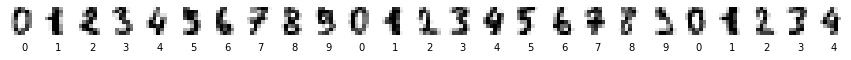

In [8]:
n=25
fig,ax = plt.subplots(1, n,figsize=(15,10))
for i in range(n):
    ax[i].set_axis_off()
    ax[i].imshow(digits['images'][i], cmap=plt.cm.gray_r, interpolation='nearest')
    ax[i].text(4.5,12.00,digits['target'][i],horizontalalignment='center')

----
## Modelling

### Support-vector machine

In [9]:
from sklearn import svm
from sklearn.model_selection import train_test_split

Initiate SVM, split the `digits` data set into train and test data, and fit.

Finally, predict labels for test data part.

In [10]:
# Create a classifier: a support vector classifier
svc = svm.SVC(gamma=0.001)

# Split data into train and test subsets
X_train, X_test, y_train, y_test = train_test_split(
    digits.data, digits.target, test_size=0.5, shuffle=False)

# We learn the digits on the first half of the digits
svc.fit(X_train, y_train)
print(100.*svc.score(X_train, y_train))

# Now predict the value of the digit on the second half:
predicted_train = svc.predict(X_train)
predicted_test = svc.predict(X_test)
print(100.*svc.score(X_test, y_test))

99.88864142538975
96.88542825361512


Plot first part of **train** data and **correct** labels.

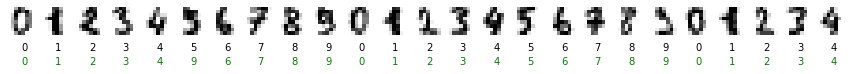

In [11]:
n=25
fig,ax = plt.subplots(1, n,figsize=(15,10))
for i in range(n):
    ax[i].set_axis_off()
    ax[i].imshow(X_train[i].reshape(8,8), cmap=plt.cm.gray_r, interpolation='nearest')
    ax[i].text(4.5,16.00,predicted_train[i],horizontalalignment='center',color='green')
    ax[i].text(4.5,12.00,y_train[i],horizontalalignment='center')

Plot the wrongly predicted digits from the **test** data set.

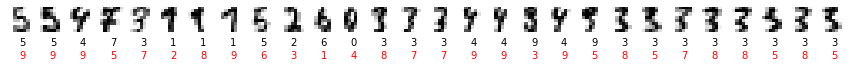

In [13]:
iwrong = 0
wrong = []
for i in range(len(predicted_test)):
    if (predicted_test[i]!=y_test[i]):
        wrong.append(i)
        iwrong += 1
        
fig,ax = plt.subplots(1, iwrong,figsize=(15,10))
iaxis=0
for i in wrong:
    ax[iaxis].set_axis_off()
    ax[iaxis].imshow(X_test[i].reshape(8,8), cmap=plt.cm.gray_r, interpolation='nearest')
    ax[iaxis].text(4.5,16.00,predicted_test[i],horizontalalignment='center',color='red')
    ax[iaxis].text(4.5,12.00,y_test[i],horizontalalignment='center')
    iaxis += 1

... done